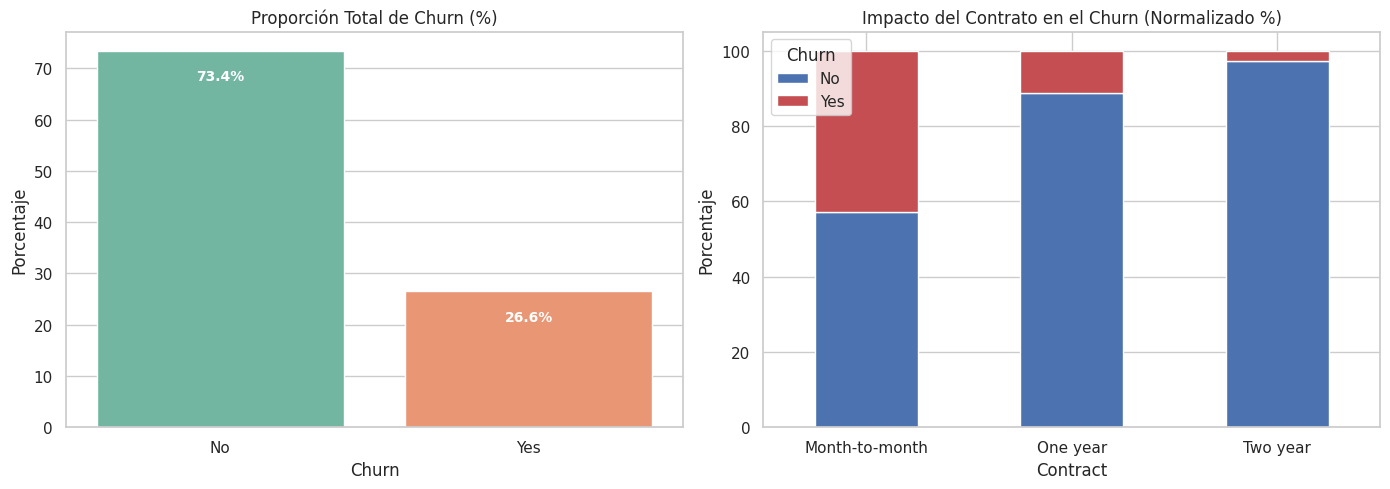

In [1]:
#1. Análisis de Distribución Relativa (Evita la trampa del conteo)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../01.data/processed/telco_churn_clean.csv")

# Configurar estilo visual limpio y profesional
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'figure.titlesize': 14})

# Crear cuadrícula para optimizar espacio (2 gráficos en 1 fila)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución Porcentual del Churn
churn_pct = df["Churn"].value_counts(normalize=True) * 100
sns.barplot(x=churn_pct.index, y=churn_pct.values, ax=axes[0], hue=churn_pct.index, legend=False, palette="Set2")
axes[0].set_title("Proporción Total de Churn (%)")
axes[0].set_ylabel("Porcentaje")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                ha='center', va='center', color='white', fontweight='bold')

# 2. Tasa de Churn Normalizada por Tipo de Contrato
# (Muestra la tasa real dentro de cada contrato, no el conteo bruto)
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c72b0", "#c44e52"])
axes[1].set_title("Impacto del Contrato en el Churn (Normalizado %)")
axes[1].set_ylabel("Porcentaje")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

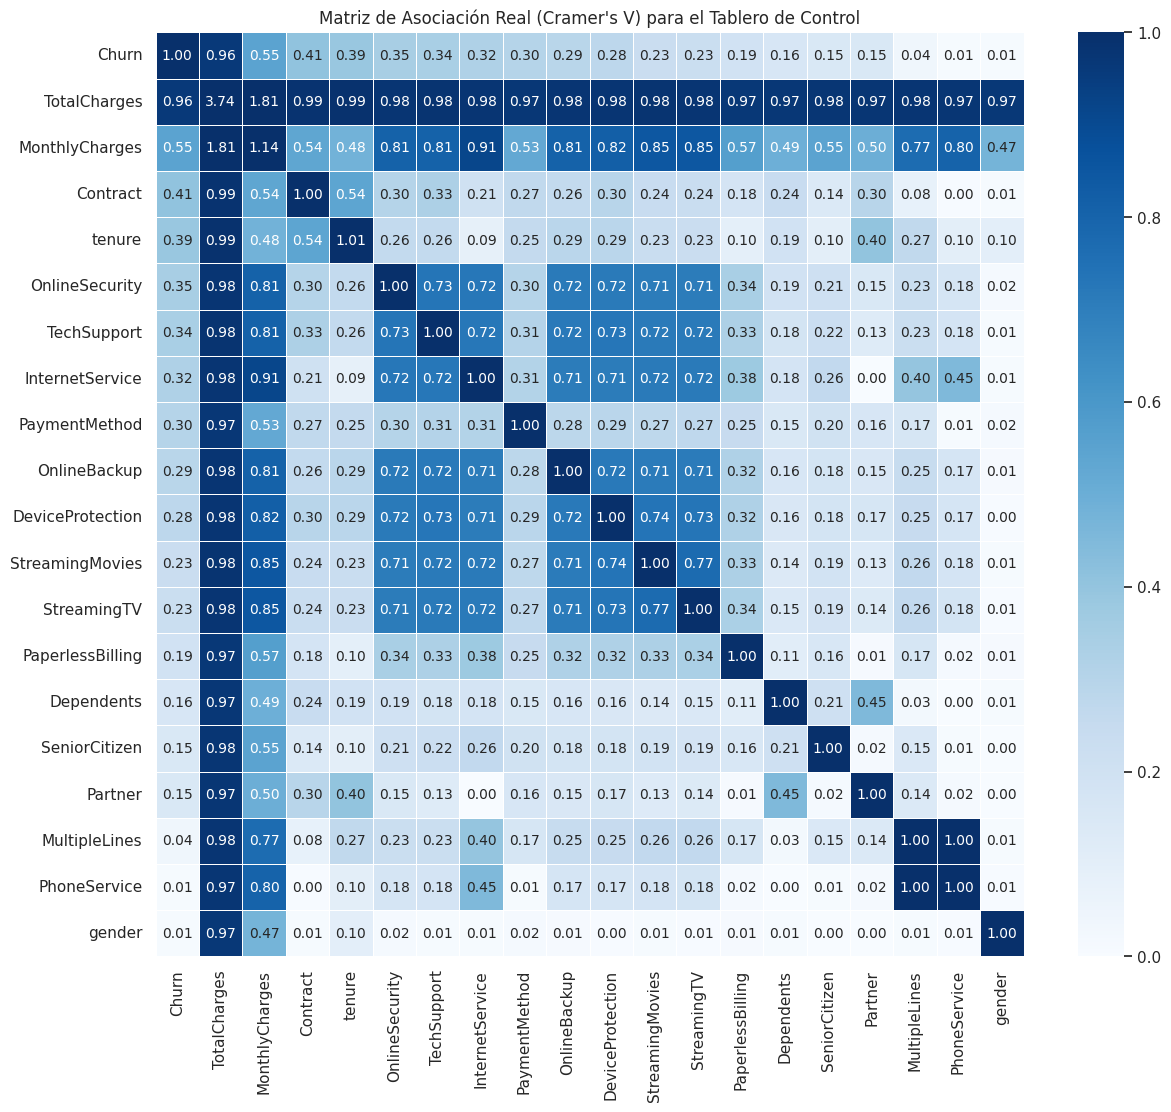

In [2]:
#2. Matriz de Correlación para Variables Categóricas (Cramer's V)
import numpy as np
import scipy.stats as stats  # Importamos el módulo base de estadística

# 1. Cargar datos asegurando tipos de Pandas modernos
df = pd.read_csv("../01.data/processed/telco_churn_clean.csv")
df_encoded = df.copy().drop(columns=["customerID"])

# Solución al Pandas4Warning
for col in df_encoded.select_dtypes(include=["object", "string"]).columns:
    df_encoded[col] = df_encoded[col].astype("category")

# 2. Función matemática para calcular Cramer's V corregida
def cramers_v(x, y):
    # Solución de contingencia: Usamos crosstab de Pandas en lugar de scipy.stats.contingency_matrix
    confusion_matrix = pd.crosstab(x, y).values
    
    n = confusion_matrix.sum()
    r, k = confusion_matrix.shape
    if n == 0 or min(r, k) <= 1:
        return 0.0
        
    # Ejecutamos la prueba Chi-cuadrado estándar
    chi2 = stats.chi2_contingency(confusion_matrix, correction=False)[0]
    
    # Corrección de sesgo de Tschuprow / Cramer
    chi2_corr = max(0, chi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    min_dim = min(k_corr - 1, r_corr - 1)
    
    if min_dim == 0:
        return 0.0
    return np.sqrt(chi2_corr / (n * min_dim))

# 3. Construir la matriz de asociación para todas las variables
cols = df_encoded.columns
n_cols = len(cols)
matrix = np.zeros((n_cols, n_cols))

for i in range(n_cols):
    for j in range(n_cols):
        matrix[i, j] = cramers_v(df_encoded.iloc[:, i], df_encoded.iloc[:, j])

df_cramer = pd.DataFrame(matrix, index=cols, columns=cols)

# 4. Graficar Heatmap corporativo en gama de azules
plt.figure(figsize=(14, 12))
top_features = df_cramer["Churn"].sort_values(ascending=False).index
sns.heatmap(
    df_cramer.loc[top_features, top_features],
    annot=True,
    fmt=".2f",
    cmap="Blues", 
    vmin=0,
    vmax=1,
    linewidths=0.5
)
plt.title("Matriz de Asociación Real (Cramer's V) para el Tablero de Control")
plt.show()



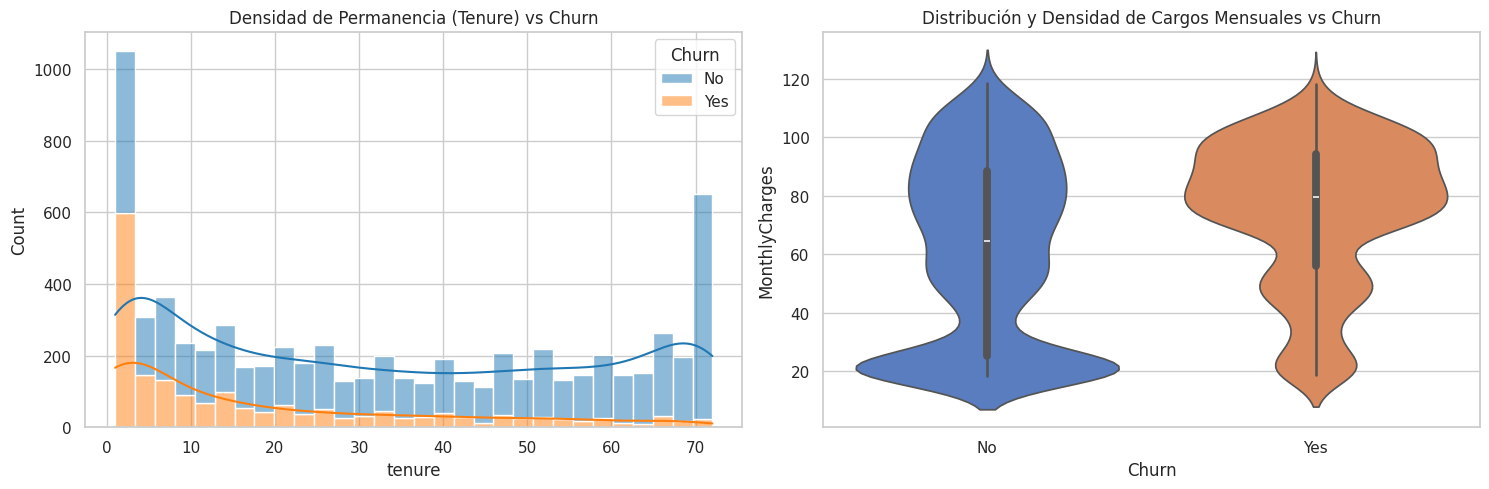

In [3]:
#3. Análisis de Comportamiento Financiero y Permanencia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de Tenure con estimación de densidad kernel (KDE) por clase
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, bins=30, ax=axes[0], multiple="stack", palette="tab10")
axes[0].set_title("Densidad de Permanencia (Tenure) vs Churn")

# Relación de Cargos Mensuales con violines (Aporta más información de densidad que el boxplot estándar)
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], hue="Churn", legend=False, palette="muted")
axes[1].set_title("Distribución y Densidad de Cargos Mensuales vs Churn")

plt.tight_layout()
plt.show()